# Fraud detection with XGBoost

Inspired by
- [XGBoost in Python from Start to Finish](https://www.youtube.com/watch?v=GrJP9FLV3FE) 


### For macOS users

You may get an error about **OpenMP** / **libomp.dylib** when importing XGBoost, it is recommended to install Apple’s OpenMP runtime 

`brew install libomp`


In [8]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid", context="notebook")
from sklearn.tree import DecisionTreeClassifier, plot_tree


### Load train / validation / test



In [9]:
DATA_ROOT = Path("../../data/processed/tree")

train_df = pd.read_csv(DATA_ROOT / "train_data.csv")
val_df = pd.read_csv(DATA_ROOT / "val_data.csv")
test_df = pd.read_csv(DATA_ROOT / "test_data.csv")

feature_cols = [c for c in train_df.columns if c != "fraud"]

X_train = train_df[feature_cols]
y_train = train_df["fraud"]
X_val = val_df[feature_cols]
y_val = val_df["fraud"]
X_test = test_df[feature_cols]
y_test = test_df["fraud"]

print("Train:", train_df.shape, "| Val:", val_df.shape, "| Test:", test_df.shape)
print("Train fraud rate:", y_train.mean().round(6))
print("Val fraud rate:  ", y_val.mean().round(6))
print("Test fraud rate: ", y_test.mean().round(6))
print("Features:", len(feature_cols))

Train: (89093, 43) | Val: (87702, 43) | Test: (89093, 43)
Train fraud rate: 0.010775
Val fraud rate:   0.010946
Test fraud rate:  0.010775
Features: 42


### Train XGBoost for classification

In [10]:
pos = int((y_train == 1).sum())
neg = int((y_train == 0).sum())
scale_pos_weight = neg / max(pos, 1)

model = XGBClassifier(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=scale_pos_weight,
    random_state=1,
    tree_method="hist",
    early_stopping_rounds=50,
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=150,
)

print("Best iteration (0-based):", model.best_iteration)
print("Best validation score (aucpr):", model.best_score)

[0]	validation_0-aucpr:0.72342
[150]	validation_0-aucpr:0.93232
[300]	validation_0-aucpr:0.93692
[391]	validation_0-aucpr:0.93643
Best iteration (0-based): 341
Best validation score (aucpr): 0.9377288695691836


### XGBoost Tree Visualisation



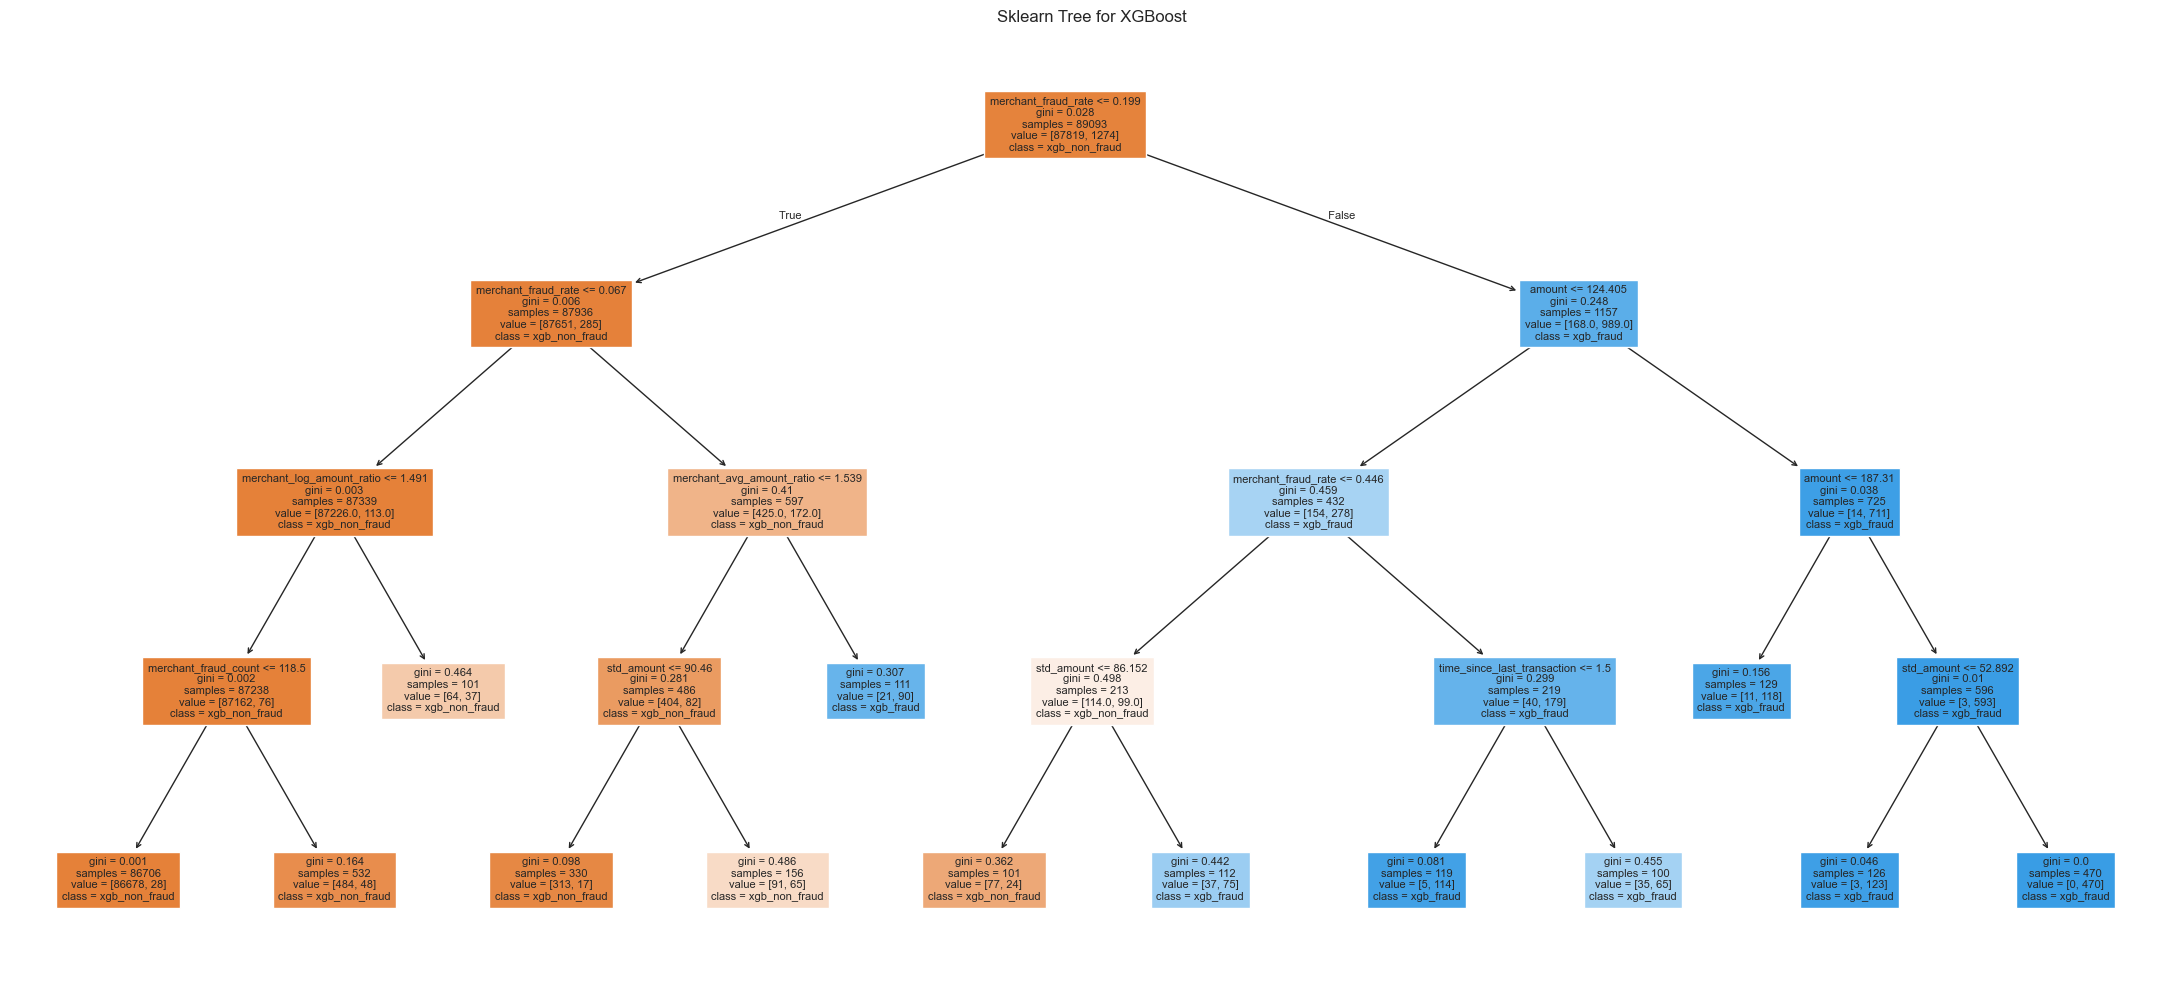

In [11]:
xgb_prob_train = model.predict_proba(X_train)[:, 1]
xgb_label_train = (xgb_prob_train >= 0.5).astype(int)

decision_tree = DecisionTreeClassifier(max_depth=4, min_samples_leaf=100, random_state=1)
decision_tree.fit(X_train, xgb_label_train)

plt.figure(figsize=(22, 10))
plot_tree(
    decision_tree,
    feature_names=feature_cols,
    class_names=["xgb_non_fraud", "xgb_fraud"],
    filled=True,
    max_depth=10,
    fontsize=8,
)
plt.title("Sklearn Tree for XGBoost")
plt.tight_layout()
plt.show()


### Test-set scores and 0.5 threshold

**ROC AUC** and  **average precision (PR AUC)** are usually more informative than accuracy for fraud.

In [12]:
prob_test = model.predict_proba(X_test)[:, 1]
threshold = 0.5
y_pred = (prob_test >= threshold).astype(int)

print(f"Threshold = {threshold}")
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:   ", recall_score(y_test, y_pred, zero_division=0))
print("F1:       ", f1_score(y_test, y_pred, zero_division=0))
print("ROC AUC:  ", roc_auc_score(y_test, prob_test))
print("PR AUC:   ", average_precision_score(y_test, prob_test))

Threshold = 0.5
Accuracy:  0.996475592919758
Precision: 0.7535321821036107
Recall:    1.0
F1:        0.8594449418084154
ROC AUC:   0.9999441540058774
PR AUC:    0.9943721826557239


### Confusion matrix based on threshold

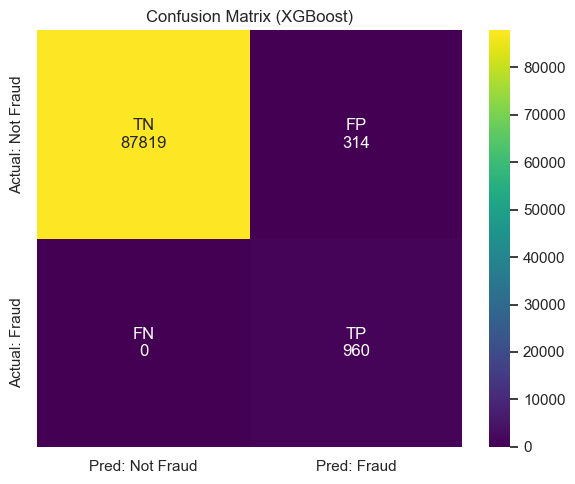

In [13]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

labels = [[f"TN\n{tn}", f"FP\n{fp}"], [f"FN\n{fn}", f"TP\n{tp}"]]

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=labels,
    fmt="",
    cmap="viridis",
    xticklabels=["Pred: Not Fraud", "Pred: Fraud"],
    yticklabels=["Actual: Not Fraud", "Actual: Fraud"],
    ax=ax,
)
ax.set_title("Confusion Matrix (XGBoost)")
plt.tight_layout()
plt.show()

### Feature importance

,feature,importance
0,merchant_fraud_count,0.395286
1,merchant_fraud_rate,0.383801
2,merchant_transaction_count,0.025609
3,global_z_score,0.014053
4,merchant_std_amount,0.012916
5,merchant_avg_amount,0.010675
6,avg_amount,0.009339
7,merchant_amount_zscore,0.008861
8,transaction_count,0.008471
9,amount,0.008387


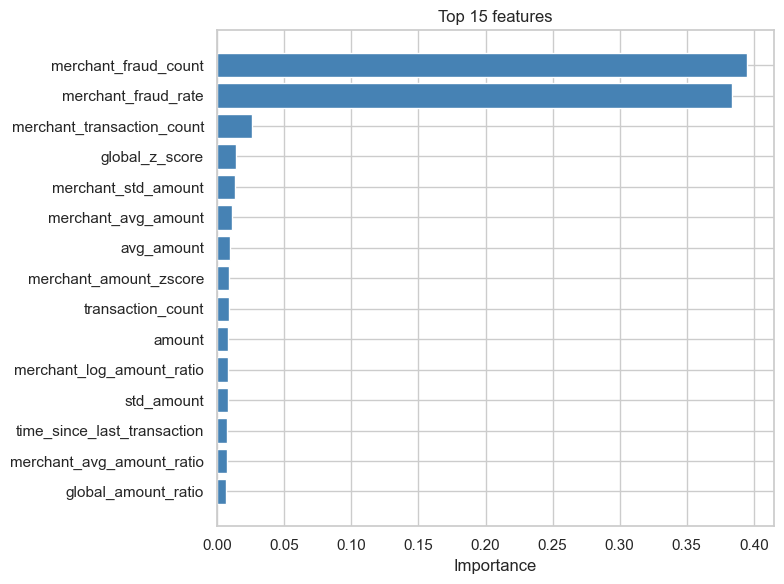

In [14]:
fi = (
    pd.DataFrame({"feature": feature_cols, "importance": model.feature_importances_})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
display(fi.head(20))

top_k = 15
sub = fi.head(top_k).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(sub["feature"], sub["importance"], color="steelblue")
ax.set_xlabel("Importance")
ax.set_title(f"Top {top_k} features")
plt.tight_layout()
plt.show()